# Machine Clustering: Tập Cụm tự động – Homi Shop

Notebook này khai thác phương pháp **Machine Learning Unsupervised (Học không giám sát): Thuật toán K-Means Clustering** được tích hợp tại `ml_service/app/services/clustering_service.py`.

## Tổng quan nghiệp vụ
Trọng tâm của phân cụm là tự động tìm ra khuynh hướng, những nhóm đối tượng có chung hệ quy chiếu. Hệ thống của chúng ta vận hành 2 kịch bản phân cụm độc lập, hỗ trợ Marketing và Sales ra quyết định:

| Phân hệ thuật toán | Các biến tham số (Features) | Ý nghĩa định danh nhãn |
|------|-----------|---------------------|
| **A. Product Insights** | `price`, `rating`, `sold`, `stock`, `img_count`, `has_3d` | Nhóm các SP theo hiệu năng bán: Sản phẩm VIP hạng sang, Hàng phổ thông bán chạy, Hàng Tồn kho khó bán... |
| **B. User Behavior Segmentation** | `total_orders`, `total_spent`, `avg_order`, `reviews` | Tái cấu trúc theo RFM: Tập Khách sộp, Tập thích Săn sale, Tập người mua 1 lần. |

## 1. Thiết lập môi trường
Để thực hiện các phân tích này, nhóm sử dụng các công cụ phổ biến trong khoa học dữ liệu:
- **Pandas & Numpy**: Xử lý dữ liệu dạng bảng và ma trận số một cách hiệu quả.
- **Matplotlib & Seaborn**: Vẽ biểu đồ và heat map trực quan.
- **Scikit-learn**: Thư viện chính để thực hiện thuật toán K-Means Clustering.

> **Lưu ý**: Chạy cell này trước tiên để setup Pandas, Numpy, Scikit-learn và các công cụ hiển thị.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


## 2. Nạp dữ liệu

In [3]:
products_raw = pd.read_csv('furniture_shop.products.csv')
reviews_raw  = pd.read_csv('furniture_shop.reviews.csv')
orders_raw   = pd.read_csv('furniture_shop.orders.csv')
categories   = pd.read_csv('furniture_shop.categories.csv')
brands       = pd.read_csv('furniture_shop.brands.csv')

cat_map   = dict(zip(categories['_id'].astype(str), categories['name']))
brand_map = dict(zip(brands['_id'].astype(str), brands['name']))
print(f'Products: {len(products_raw)}, Reviews: {len(reviews_raw)}, Orders: {len(orders_raw)}')

print('\n--- 5 bản ghi đầu tiên của mỗi bảng ---')
print('Sản phẩm:')
display(products_raw.head())
print('Đánh giá:')
display(reviews_raw.head())
print('Đơn hàng:')
display(orders_raw.head())
print('Danh mục:')
display(categories.head())
print('Thương hiệu:')
display(brands.head())

Products: 13, Reviews: 46, Orders: 64

--- 5 bản ghi đầu tiên của mỗi bảng ---
Sản phẩm:


,_id,name,sku,description,price,category,brand,stock,images[0],images[1],images[2],images[3],images[4],images[5],images[6],model3DUrl,dimensions.width,dimensions.height,dimensions.length,colors[0],colors[1],colors[2],materials[0],materials[1],materials[2],tags[0],tags[1],tags[2],averageRating,totalReviews,soldCount,createdAt,updatedAt,slug,isDeleted,__v,isFeatured
0,6933adafb53918b85561127a,Sofa Góc Lullaby,SF001,"Sofa góc Lullaby thiết kế hiện đại, bọc vải nỉ...",15000000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,9,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,160,85,200,Be sáng,Kem,NaN,Vải nỉ,NaN,NaN,sofa,hiện đại,phòng khách,2.5,2,40,2025-12-06T04:14:39.727Z,2026-04-05T03:51:45.179Z,sofa-goc-lullaby,False,0,False
1,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,SF002,"Sofa băng 3 chỗ ngồi bọc da bò Ý nhập khẩu, ch...",28500000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,0,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/up...,90,90,220,Nâu bò,Đen,NaN,Da thật,Thép,NaN,Sofa,Da thật,Sang trọng,3.0,2,41,2025-12-06T05:50:24.767Z,2026-04-05T03:51:45.179Z,sofa-bang-da-bo-that,False,0,False
2,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,SF003,"Sofa có thể mở ra thành giường ngủ, giải pháp ...",8500000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,12,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/upl...,85,80,180,Xanh Navy,NaN,NaN,Vải bố,Khung gỗ,NaN,Sofa bed,Thông minh,Nhỏ gọn,3.0,3,43,2025-12-06T06:01:03.379Z,2026-04-05T03:51:45.179Z,sofa-giuong-thong-minh,False,0,NaN
3,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,SF004,"Ghế sofa đơn kèm đôn gác chân, thiết kế ôm sát...",4200000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,18,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,80,100,Be,Kem,Nâu,Nhung,Da thật,Gỗ,Sofa,Thư giãn,Đọc sách,4.0,1,55,2025-12-06T06:28:42.053Z,2026-04-05T03:51:45.179Z,sofa-don-thu-gian,False,0,True
4,6933cfb22ea2861093a39b5b,Bàn Trà Kính Tròn,BT001,"Bàn trà mặt kính cường lực, chân gỗ sang trọng.",2500000,693296f6ba0c79a52537afd9,69329f0de26db821bb576a9c,26,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,40,80,Vàng,Nâu,NaN,Kính cường lực,Gỗ,NaN,Bàn trà,Hiện đại,Kính,5.0,1,47,2025-12-06T06:39:46.473Z,2026-04-05T03:51:45.179Z,ban-tra-kinh-tron,False,2,True


Đánh giá:


,_id,product,user,rating,comment,createdAt,updatedAt,__v
0,22fb3331d2d37e4554dff67c,6933c4202ea2861093a39b34,b147c5a48776c6549027856c,5,"rat tot, yeu thich mau sac va do ben",2025-12-07T08:11:00Z,2025-12-07T08:11:00Z,0
1,1be3094c137ea70682b7ced8,6933c69f2ea2861093a39b3d,b147c5a48776c6549027856c,4,"good quality, hai long, worth the money",2025-12-18T07:46:00Z,2025-12-18T07:46:00Z,0
2,982758f693541b2894409746,6933d83cf17e1b6d5ec15b0b,b147c5a48776c6549027856c,3,o muc chap nhan duoc cho tam gia,2025-12-07T17:22:00Z,2025-12-07T17:22:00Z,0
3,7656563c180802f863cf0636,6933adafb53918b85561127a,b147c5a48776c6549027856c,4,"great product, recommend for family use",2026-04-05T01:57:00Z,2026-04-05T01:57:00Z,0
4,73bece9989e05fd4355a3b07,6933cfb22ea2861093a39b5b,50d83bf3615543cb3a606532,4,"good quality, hai long, worth the money",2026-02-14T04:16:00Z,2026-02-14T04:16:00Z,0


Đơn hàng:


,_id,user,code,items[0].product,items[0].name,items[0].quantity,items[0].price,items[0].image,items[0]._id,items[1].product,items[1].name,items[1].quantity,items[1].price,items[1].image,items[1]._id,items[2].product,items[2].name,items[2].quantity,items[2].price,items[2].image,items[2]._id,shippingAddress.fullName,shippingAddress.phone,shippingAddress.province,shippingAddress.district,shippingAddress.ward,shippingAddress.address,payment.method,payment.status,payment.transactionId,status,subTotal,shippingFee,discount.code,discount.amount,totalAmount,notes,createdAt,updatedAt,__v
0,8a8ccaf002abb07b531a9d72,b147c5a48776c6549027856c,ORD261001,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,2,8900000,https://res.cloudinary.com/drgho551x/image/upl...,a74bf5b9374a3fd70410d71d,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,d91c182cbc0772cdff8b72bb,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,3.0,8500000.0,https://res.cloudinary.com/drgho551x/image/upl...,94e70ecd02a83d45405604c9,Nguyen Minh,999475954,Da Nang,Cau Giay,Thach Thang,622 Nguyen Van Linh,BANK,pending,TX160155081585,processing,73300000,0,FLASH20,0,73300000,Seed dataset for recommendation and analytics,2026-01-19T19:14:00Z,2026-01-19T19:14:00Z,0
1,95844b6b2d8ce234d67e8fb0,b147c5a48776c6549027856c,ORD261002,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,1,8900000,https://res.cloudinary.com/drgho551x/image/upl...,072f1b71139594bcee04a773,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,b2fd568f00e6f9af62ef9575,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,912561677,Can Tho,Hai Chau,An Hoa,773 Nguyen Van Linh,BANK,completed,TX206683887955,delivered,65900000,45000,WELCOME10,100000,65845000,Seed dataset for recommendation and analytics,2026-01-01T03:05:00Z,2026-01-01T03:05:00Z,0
2,2f719f554d2dcac3fcf750b8,b147c5a48776c6549027856c,ORD261003,6933adafb53918b85561127a,Sofa Góc Lullaby,3,15000000,https://res.cloudinary.com/drgho551x/image/upl...,ddd1669b24417f755b132524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,992701085,Ho Chi Minh,Quan 1,Dich Vong,992 Nguyen Van Linh,COD,pending,NaN,processing,45000000,0,WELCOME10,250000,44750000,Seed dataset for recommendation and analytics,2025-12-08T13:58:00Z,2025-12-08T13:58:00Z,0
3,d85ff734b88de3690a8e8335,b147c5a48776c6549027856c,ORD261004,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,3,8900000,https://res.cloudinary.com/drgho551x/image/upl...,0868533749af3c0487a79df5,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,249159cd47dfbd2566fbd195,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,ea6ea560994dd2465894d7f3,Nguyen Minh,959813731,Da Nang,Quan 1,Thach Thang,716 Nguyen Van Linh,COD,completed,NaN,delivered,113700000,45000,VIP50,100000,113645000,Seed dataset for recommendation and analytics,2026-01-02T20:58:00Z,2026-01-02T20:58:00Z,0
4,88af292d03dec8f70f820a7f,50d83bf3615543cb3a606532,ORD261005,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,2,4200000,https://res.cloudinary.com/drgho551x/image/upl...,174b7454fa0da64f0c7201cb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tran Lan,940960299,Da Nang,Cau Giay,Thach Thang,555 Nguyen Van Linh,BANK,completed,TX442660673649,delivered,8400000,45000,WELCOME10,100000,8345000,Seed dataset for recommendation and analytics,2025-11-19T10:25:00Z,2025-11-19T10:25:00Z,0


Danh mục:


,_id,name,description,parentCategory,createdAt,updatedAt,slug,__v,image
0,69328dd8ed938f60e00a086c,Phòng khách,Nội thất sang trọng cho phòng khách,NaN,2025-12-05T07:46:32.161Z,2025-12-05T07:46:32.161Z,phong-khach,0,https://res.cloudinary.com/drgho551x/image/upl...
1,69328eb5ed938f60e00a0879,Phòng ngủ,Không gian ấm cúng cho giấc ngủ,NaN,2025-12-05T07:50:13.855Z,2025-12-05T07:50:13.855Z,phong-ngu,0,https://res.cloudinary.com/drgho551x/image/upl...
2,69328ef0ed938f60e00a087f,Phòng bếp,Tiện nghi cho gian bếp hiện đại,NaN,2025-12-05T07:51:12.219Z,2025-12-05T07:51:12.219Z,phong-bep,0,https://res.cloudinary.com/drgho551x/image/upl...
3,69328effed938f60e00a0885,Văn phòng,Bàn ghế làm việc chuyên nghiệp,NaN,2025-12-05T07:51:27.950Z,2025-12-05T07:51:27.950Z,van-phong,0,https://res.cloudinary.com/drgho551x/image/upl...
4,693296dbba0c79a52537afd1,Sofa,Các loại ghế Sofa cao cấp,69328dd8ed938f60e00a086c,2025-12-05T08:24:59.874Z,2025-12-05T08:24:59.874Z,sofa,0,https://res.cloudinary.com/drgho551x/image/upl...


Thương hiệu:


,_id,name,image,description,createdAt,updatedAt,slug,__v
0,69329ddf63a83d44a1f5207c,IKEA,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu nội thất Thụy Điển,2025-12-05T08:54:55.673Z,2025-12-05T08:54:55.673Z,ikea,0
1,69329f0de26db821bb576a9c,Hòa Phát,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu quốc gia Việt Nam,2025-12-05T08:59:57.035Z,2025-12-21T05:48:12.724Z,hoa-phat,0
2,69329f50e26db821bb576aa3,Ashley Furniture,https://res.cloudinary.com/drgho551x/image/upl...,Nội thất cao cấp từ Mỹ,2025-12-05T09:01:04.942Z,2025-12-05T09:01:04.942Z,ashley-furniture,0
3,69478a5dddae8440bc6440a7,Homi,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu Homi là thương hiệu sản xuất của c...,2025-12-21T05:49:17.933Z,2025-12-21T05:49:17.933Z,homi,0


## 3. PART A – Thiết lập mạng lưới phân Cụm Sản Phẩm (Product Clustering)

Dữ liệu của Products được gom nhóm qua các chỉ tiêu định lượng cứng yếu tố mua bán (Bỏ qua định tính text content).
```python
features = ['price', 'average_rating', 'total_reviews', 'sold_count', 'stock', 'image_count', 'has_3d']
```

In [4]:
# BUILD PRODUCT FEATURES
prod_rows = []
for _, p in products_raw.iterrows():
    img_cols  = [c for c in products_raw.columns if c.startswith('images[')]
    img_count = int(pd.notna(p[img_cols]).sum())
    has_3d    = 1.0 if (pd.notna(p.get('model3DUrl','')) and str(p.get('model3DUrl','')) not in ('', 'nan')) else 0.0

    prod_rows.append({
        'product_id'    : str(p['_id']),
        'name'          : str(p.get('name', '')),
        'category'      : cat_map.get(str(p.get('category','')), ''),
        'brand'         : brand_map.get(str(p.get('brand','')), ''),
        'price'         : float(p.get('price', 0) or 0),
        'average_rating': float(p.get('averageRating', 0) or 0),
        'total_reviews' : float(p.get('totalReviews', 0) or 0),
        'sold_count'    : float(p.get('soldCount', 0) or 0),
        'stock'         : float(p.get('stock', 0) or 0),
        'image_count'   : float(img_count),
        'has_3d'        : has_3d,
    })

prod_df = pd.DataFrame(prod_rows)
print(f'Product feature DataFrame: {prod_df.shape}')

# Xem phân phối của các features
feature_cols_p = ['price','average_rating','total_reviews','sold_count','stock','image_count','has_3d']
prod_df[feature_cols_p].describe()

Product feature DataFrame: (13, 11)


,price,average_rating,total_reviews,sold_count,stock,image_count,has_3d
count,1.300000e+01,13.000000,13.000000,13.000000,13.000000,13.000000,13.0
mean,7.538462e+06,2.846154,1.538462,46.692308,14.000000,4.461538,1.0
std,7.570726e+06,1.448916,0.967418,8.340510,7.404953,1.391365,0.0
min,5.000000e+05,0.000000,0.000000,30.000000,0.000000,3.000000,1.0
25%,2.500000e+06,2.500000,1.000000,41.000000,10.000000,3.000000,1.0
50%,4.200000e+06,3.000000,2.000000,46.000000,12.000000,4.000000,1.0
75%,8.900000e+06,4.000000,2.000000,55.000000,18.000000,6.000000,1.0
max,2.850000e+07,5.000000,3.000000,60.000000,27.000000,7.000000,1.0


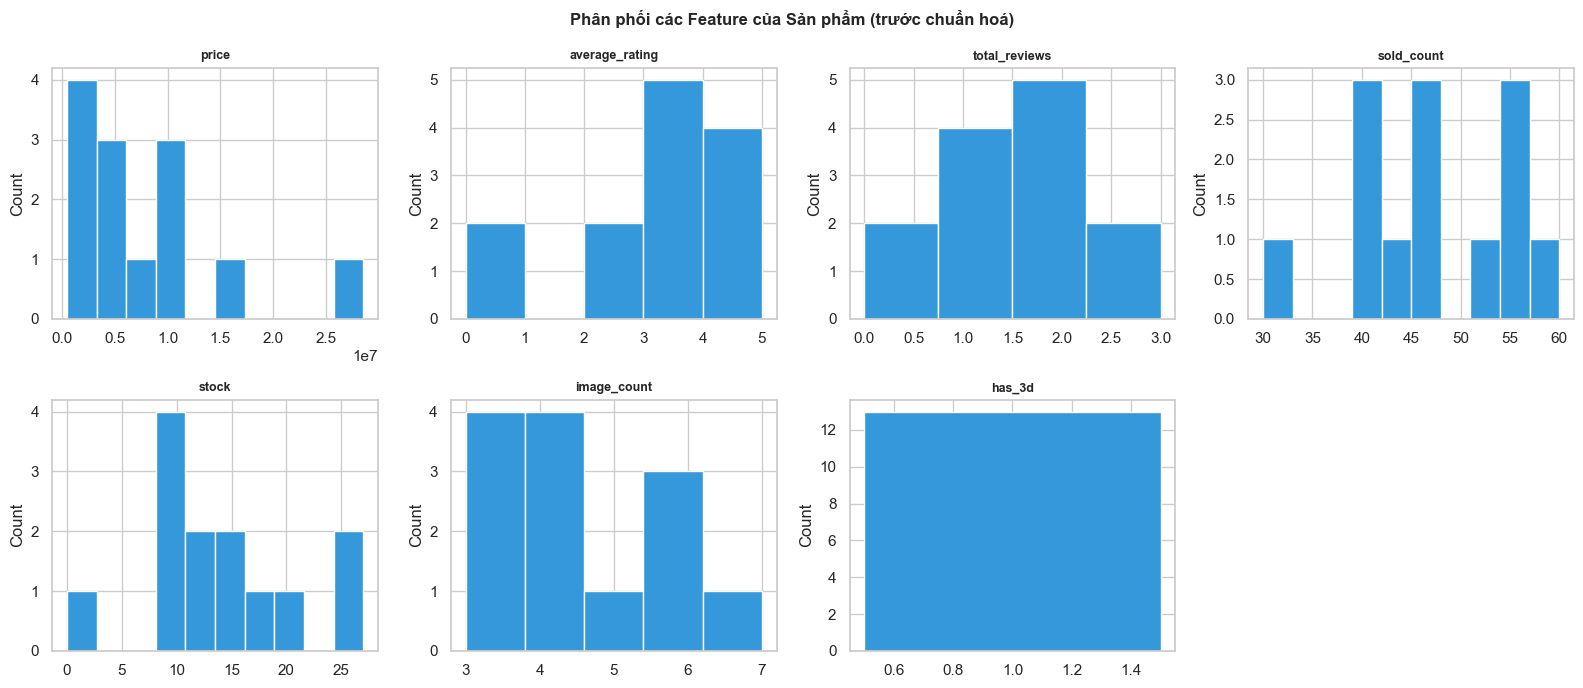

In [5]:
# Visualise feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols_p):
    axes[i].hist(prod_df[col], bins=min(10, prod_df[col].nunique()), color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
plt.suptitle('Phân phối các Feature của Sản phẩm (trước chuẩn hoá)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 StandardScaler → K-Means

In [6]:
N_CLUSTERS_PRODUCTS = 4

X_prod   = prod_df[feature_cols_p].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_prod)

# K-Means với n_init=20 (như trong clustering_service.py)
kmeans_p = KMeans(n_clusters=N_CLUSTERS_PRODUCTS, random_state=42, n_init=20)
prod_df['cluster'] = kmeans_p.fit_predict(X_scaled)

print(f'Phân cụm xong: {N_CLUSTERS_PRODUCTS} cụm sản phẩm')
print('\nPhân phối sản phẩm theo cụm:')
print(prod_df['cluster'].value_counts().sort_index())

Phân cụm xong: 4 cụm sản phẩm

Phân phối sản phẩm theo cụm:
cluster
0    3
1    2
2    3
3    5
Name: count, dtype: int64


### 3.2 Gán nhãn Logic (Rule-Based Labeling)

K-Means chỉ trả về số cụm (Cluster 0, Cluster 1). Nhờ sự trợ giúp của phương pháp thống kê **Quantile (Phân vị)**, model tự định danh đặc trưng của Cụm đó (Ví dụ: Cụm 1 có Price cao hơn 80% thị trường -> 'Cao Cấp').

In [7]:
# PRODUCT_LABEL_RULES từ cluster_label_config.py
PRODUCT_LABEL_RULES = [
    {'label': 'Premium chất lượng cao', 'all': [
        ('price', '>=', 'price_p75'), ('average_rating', '>=', 'rating_p75')]},
    {'label': 'Bán chạy', 'all': [
        ('sold_count', '>=', 'sold_p75'), ('total_reviews', '>=', 'reviews_p75')]},
    {'label': 'Tồn kho cao bán chậm', 'all': [
        ('stock', '>=', 'stock_p75'), ('sold_count', '<=', 'sold_p25')]},
    {'label': 'Giá tốt bán ổn', 'all': [
        ('price', '<=', 'price_p25'), ('sold_count', '>=', 'sold_p50')]},
]
PRODUCT_DEFAULT_LABEL = 'Nhóm phổ thông'

def compute_thresholds(df):
    return {
        'price_p25'   : df['price'].quantile(0.25),
        'price_p75'   : df['price'].quantile(0.75),
        'rating_p75'  : df['average_rating'].quantile(0.75),
        'sold_p25'    : df['sold_count'].quantile(0.25),
        'sold_p50'    : df['sold_count'].quantile(0.50),
        'sold_p75'    : df['sold_count'].quantile(0.75),
        'reviews_p75' : df['total_reviews'].quantile(0.75),
        'stock_p75'   : df['stock'].quantile(0.75),
    }

def compare(left, op, right):
    ops = {'>=': left>=right, '<=': left<=right, '>': left>right, '<': left<right, '==': left==right}
    return ops.get(op, False)

def pick_label(cluster_stats, thresholds, rules, default):
    for rule in rules:
        all_match = all(
            compare(float(cluster_stats.get(f, 0)), op, float(thresholds.get(t, 0)))
            for f, op, t in rule['all']
        )
        if all_match:
            return rule['label']
    return default

thresholds = compute_thresholds(prod_df)
print('📐 Ngưỡng phân loại (quantile):')
for k, v in thresholds.items():
    print(f'   {k:<15}: {v:,.1f}')

📐 Ngưỡng phân loại (quantile):
   price_p25      : 2,500,000.0
   price_p75      : 8,900,000.0
   rating_p75     : 4.0
   sold_p25       : 41.0
   sold_p50       : 46.0
   sold_p75       : 55.0
   reviews_p75    : 2.0
   stock_p75      : 18.0


In [9]:
# Tính cluster stats và gán nhãn
cluster_summaries = {}
for cid in sorted(prod_df['cluster'].unique()):
    rows = prod_df[prod_df['cluster'] == cid]
    means = {col: float(rows[col].mean()) for col in feature_cols_p}
    label = pick_label(means, thresholds, PRODUCT_LABEL_RULES, PRODUCT_DEFAULT_LABEL)
    cluster_summaries[cid] = {'cluster': cid, 'label': label, 'size': len(rows), 'avg_features': means}

prod_df['cluster_label'] = prod_df['cluster'].map({k: v['label'] for k, v in cluster_summaries.items()})

# Hiển thị tóm tắt
print('\nCLUSTER SUMMARIES – PRODUCTS')
print('='*60)
for cid, s in cluster_summaries.items():
    print(f"\nCụm {cid}: [{s['label']}] – {s['size']} sản phẩm")
    for feat, val in s['avg_features'].items():
        print(f"    {feat:<18}: {val:>10,.2f}")


CLUSTER SUMMARIES – PRODUCTS

Cụm 0: [Nhóm phổ thông] – 3 sản phẩm
    price             : 3,800,000.00
    average_rating    :       3.17
    total_reviews     :       2.33
    sold_count        :      38.33
    stock             :      11.67
    image_count       :       3.33
    has_3d            :       1.00

Cụm 1: [Nhóm phổ thông] – 2 sản phẩm
    price             : 6,750,000.00
    average_rating    :       0.00
    total_reviews     :       0.00
    sold_count        :      50.00
    stock             :      15.00
    image_count       :       3.50
    has_3d            :       1.00

Cụm 2: [Nhóm phổ thông] – 3 sản phẩm
    price             : 17,333,333.33
    average_rating    :       2.83
    total_reviews     :       2.33
    sold_count        :      41.33
    stock             :       7.00
    image_count       :       6.33
    has_3d            :       1.00

Cụm 3: [Nhóm phổ thông] – 5 sản phẩm
    price             : 4,220,000.00
    average_rating    :       3.80
    

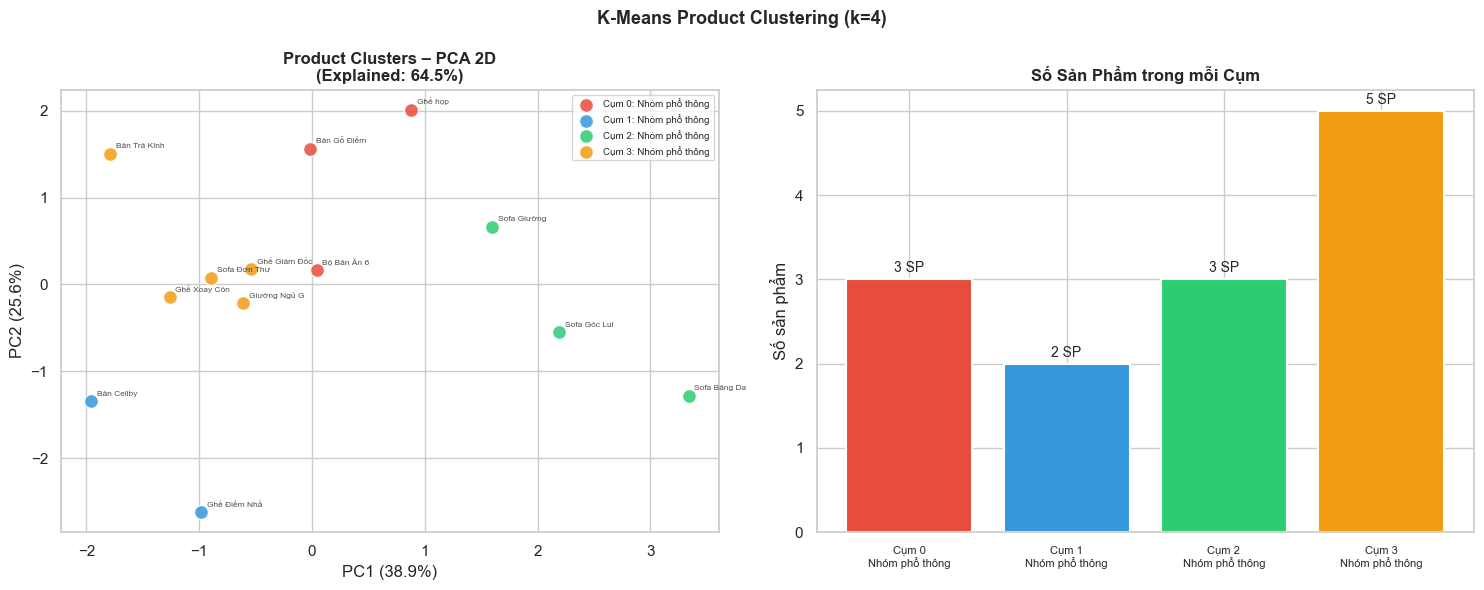

Đã lưu: product_clustering_result.png


In [11]:
# Visualise kết quả Product Clustering
CLUSTER_COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
unique_clusters = sorted(prod_df['cluster'].unique())
color_map = {c: CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i, c in enumerate(unique_clusters)}

# PCA để visualise 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
prod_df['pca1'] = X_pca[:, 0]
prod_df['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter
for cid in unique_clusters:
    mask = prod_df['cluster'] == cid
    label = cluster_summaries[cid]['label']
    axes[0].scatter(prod_df[mask]['pca1'], prod_df[mask]['pca2'],
                    c=color_map[cid], label=f'Cụm {cid}: {label}', s=100, alpha=0.85, edgecolors='white', linewidths=1)
    # Annotate product names
    for _, row in prod_df[mask].iterrows():
        axes[0].annotate(row['name'][:12], (row['pca1'], row['pca2']),
                         textcoords='offset points', xytext=(4, 4), fontsize=6, alpha=0.8)

axes[0].set_title(f'Product Clusters – PCA 2D\n(Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=7, loc='best')

# Bar chart cluster sizes
labels = [f"Cụm {k}\n{v['label'][:20]}" for k, v in cluster_summaries.items()]
sizes  = [v['size'] for v in cluster_summaries.values()]
colors = [color_map[k] for k in cluster_summaries.keys()]
bars   = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars, fmt='%d SP', padding=3, fontsize=10)
axes[1].set_title('Số Sản Phẩm trong mỗi Cụm', fontweight='bold')
axes[1].set_ylabel('Số sản phẩm')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('K-Means Product Clustering (k=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('product_clustering_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: product_clustering_result.png')

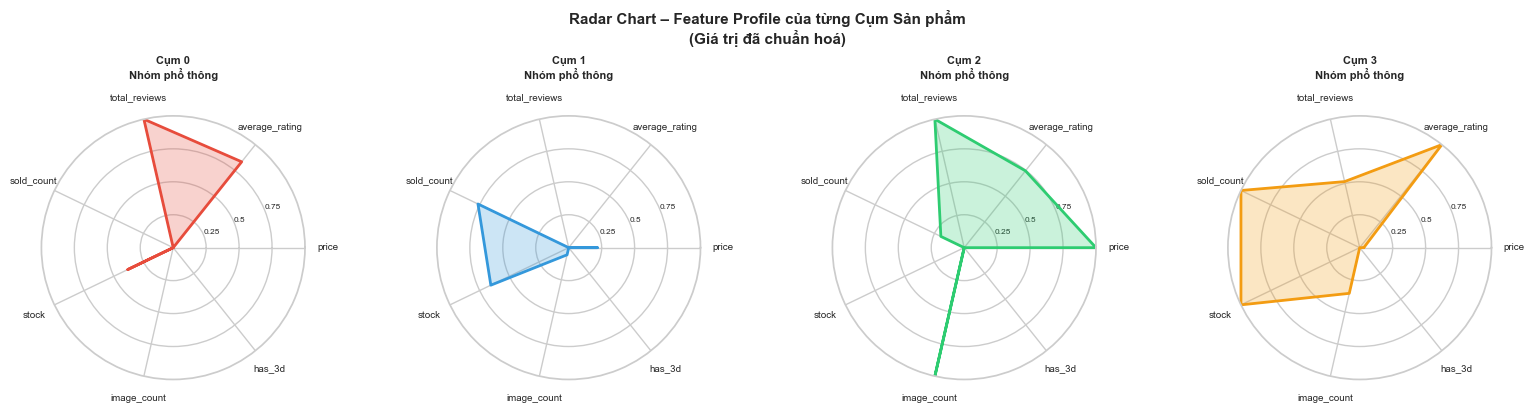

In [12]:
# Radar chart – Feature profile of each cluster
from matplotlib.patches import FancyArrowPatch

features_display = feature_cols_p
n_feat = len(features_display)
angles = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

# Normalize cluster means to [0,1]
cluster_means = pd.DataFrame({k: v['avg_features'] for k, v in cluster_summaries.items()}).T
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

fig, axes = plt.subplots(1, len(cluster_summaries), figsize=(16, 4), subplot_kw=dict(polar=True))
if len(cluster_summaries) == 1:
    axes = [axes]

for i, (cid, ax) in enumerate(zip(sorted(cluster_summaries.keys()), axes)):
    values = cluster_means_norm.loc[cid, features_display].tolist()
    values += values[:1]
    color = CLUSTER_COLORS[i % len(CLUSTER_COLORS)]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_display, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.5','0.75'], fontsize=6)
    ax.set_title(f"Cụm {cid}\n{cluster_summaries[cid]['label']}", fontsize=8, fontweight='bold', pad=10)

plt.suptitle('Radar Chart – Feature Profile của từng Cụm Sản phẩm\n(Giá trị đã chuẩn hoá)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. PART B – Phân đoạn Khách hàng (User Behavior Segmentation)

Chuyển qua phân tích Người dùng. Model tạo lập không gian đặc trưng từ hoạt động tổng kết ví tiền và phản hồi.
```python
features = ['total_orders', 'total_qty', 'total_spent', 'avg_order_value', 'total_reviews', 'avg_rating']
```

In [13]:
# BUILD USER FEATURES (tái hiện kmeans_clustering() cluster_type='users')
user_stats = defaultdict(lambda: {'total_orders':0.0,'total_qty':0.0,'total_spent':0.0,
                                   'total_reviews':0.0,'avg_rating_sum':0.0})

item_p_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.product')]
item_q_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.quantity')]

for _, o in orders_raw.iterrows():
    uid = str(o['user'])
    user_stats[uid]['total_orders'] += 1
    user_stats[uid]['total_spent']  += float(o.get('totalAmount', 0) or 0)
    for qc in item_q_cols:
        qty = o.get(qc)
        if pd.notna(qty):
            user_stats[uid]['total_qty'] += float(qty)

for _, r in reviews_raw.iterrows():
    uid = str(r['user'])
    user_stats[uid]['total_reviews']  += 1
    user_stats[uid]['avg_rating_sum'] += float(r.get('rating', 0) or 0)

user_rows = []
for uid, stats in user_stats.items():
    avg_rating = stats['avg_rating_sum'] / stats['total_reviews'] if stats['total_reviews'] else 0
    avg_order  = stats['total_spent']   / stats['total_orders']   if stats['total_orders']  else 0
    user_rows.append({
        'user_id'       : uid,
        'total_orders'  : stats['total_orders'],
        'total_qty'     : stats['total_qty'],
        'total_spent'   : stats['total_spent'],
        'avg_order_value': avg_order,
        'total_reviews' : stats['total_reviews'],
        'avg_rating'    : avg_rating,
    })

user_df = pd.DataFrame(user_rows)
feature_cols_u = ['total_orders','total_qty','total_spent','avg_order_value','total_reviews','avg_rating']
print(f'User feature DataFrame: {user_df.shape}')
user_df.describe()

User feature DataFrame: (12, 7)


,total_orders,total_qty,total_spent,avg_order_value,total_reviews,avg_rating
count,12.000000,12.000000,1.200000e+01,1.200000e+01,12.000000,12.000000
mean,5.333333,19.833333,1.366246e+08,2.677328e+07,3.833333,3.358333
std,1.230915,6.278873,7.317678e+07,1.718537e+07,0.937437,0.914212
min,4.000000,12.000000,6.209500e+07,1.034917e+07,3.000000,2.000000
25%,4.000000,16.250000,7.912000e+07,1.717446e+07,3.000000,2.766667
50%,5.000000,19.500000,1.248100e+08,1.917911e+07,3.500000,3.416667
75%,6.250000,22.000000,1.608938e+08,3.289616e+07,5.000000,4.000000
max,7.000000,36.000000,2.975400e+08,7.438500e+07,5.000000,5.000000


In [14]:
N_CLUSTERS_USERS = 4
n_users = len(user_df)
n_clusters_u = max(2, min(N_CLUSTERS_USERS, n_users)) if n_users > 1 else 1

X_user   = user_df[feature_cols_u].values
scaler_u = StandardScaler()
X_usscaled = scaler_u.fit_transform(X_user)

kmeans_u = KMeans(n_clusters=n_clusters_u, random_state=42, n_init=20)
user_df['cluster'] = kmeans_u.fit_predict(X_usscaled)

print(f'Phân cụm xong: {n_clusters_u} cụm người dùng')
print(user_df['cluster'].value_counts().sort_index())

Phân cụm xong: 4 cụm người dùng
cluster
0    3
1    5
2    3
3    1
Name: count, dtype: int64


In [15]:
# USER LABEL RULES từ cluster_label_config.py
USER_LABEL_RULES = [
    {'label': 'Khách VIP trung thành', 'all': [
        ('total_spent', '>=', 'spent_p75'), ('total_orders', '>=', 'orders_p75')]},
    {'label': 'Mua thường xuyên', 'all': [
        ('total_orders', '>=', 'orders_p75'), ('avg_order_value', '<=', 'avg_order_p50')]},
    {'label': 'Giá trị đơn cao', 'all': [
        ('avg_order_value', '>=', 'avg_order_p75'), ('total_orders', '<=', 'orders_p50')]},
    {'label': 'Tương tác cao', 'all': [
        ('total_reviews', '>=', 'reviews_p75')]},
]
USER_DEFAULT_LABEL = 'Khách hàng phổ thông'

u_thresh = {
    'spent_p75'     : user_df['total_spent'].quantile(0.75),
    'orders_p50'    : user_df['total_orders'].quantile(0.50),
    'orders_p75'    : user_df['total_orders'].quantile(0.75),
    'avg_order_p50' : user_df['avg_order_value'].quantile(0.50),
    'avg_order_p75' : user_df['avg_order_value'].quantile(0.75),
    'reviews_p75'   : user_df['total_reviews'].quantile(0.75),
}

user_summaries = {}
for cid in sorted(user_df['cluster'].unique()):
    rows  = user_df[user_df['cluster'] == cid]
    means = {col: float(rows[col].mean()) for col in feature_cols_u}
    label = pick_label(means, u_thresh, USER_LABEL_RULES, USER_DEFAULT_LABEL)
    user_summaries[cid] = {'cluster': cid, 'label': label, 'size': len(rows), 'avg_features': means}

user_df['cluster_label'] = user_df['cluster'].map({k: v['label'] for k, v in user_summaries.items()})

print('\nCLUSTER SUMMARIES – USERS')
print('='*60)
for cid, s in user_summaries.items():
    print(f"Cụm {cid}: [{s['label']}] – {s['size']} users")
    for feat, val in s['avg_features'].items():
        print(f"    {feat:<20}: {val:>12,.2f}")


CLUSTER SUMMARIES – USERS
Cụm 0: [Khách hàng phổ thông] – 3 users
    total_orders        :         7.00
    total_qty           :        26.33
    total_spent         : 159,006,666.67
    avg_order_value     : 22,715,238.10
    total_reviews       :         3.00
    avg_rating          :         4.00
Cụm 1: [Khách hàng phổ thông] – 5 users
    total_orders        :         5.20
    total_qty           :        19.00
    total_spent         : 128,407,000.00
    avg_order_value     : 25,365,033.33
    total_reviews       :         3.60
    avg_rating          :         3.10
Cụm 2: [Tương tác cao] – 3 users
    total_orders        :         4.33
    total_qty           :        14.67
    total_spent         : 74,300,000.00
    avg_order_value     : 17,307,833.33
    total_reviews       :         5.00
    avg_rating          :         2.93
Cụm 3: [Giá trị đơn cao] – 1 users
    total_orders        :         4.00
    total_qty           :        20.00
    total_spent         : 297,540,000

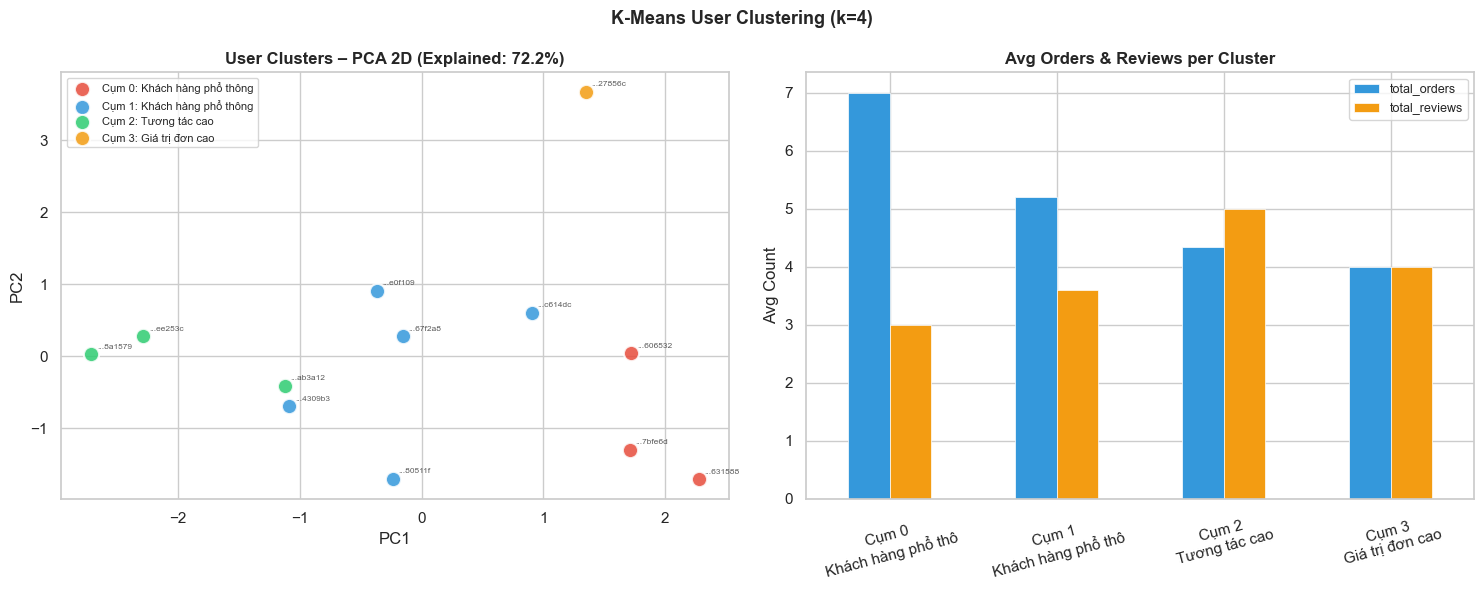

Đã lưu: user_clustering_result.png


In [16]:
# Visualise User Clustering
unique_clusters_u = sorted(user_df['cluster'].unique())
color_map_u = {c: CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i, c in enumerate(unique_clusters_u)}

if len(X_usscaled[0]) > 2:
    pca_u = PCA(n_components=2, random_state=42)
    X_pca_u = pca_u.fit_transform(X_usscaled)
    user_df['pca1'] = X_pca_u[:, 0]
    user_df['pca2'] = X_pca_u[:, 1]
    expl = pca_u.explained_variance_ratio_.sum() * 100
else:
    user_df['pca1'] = X_usscaled[:, 0]
    user_df['pca2'] = X_usscaled[:, 1]
    expl = 100.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cid in unique_clusters_u:
    mask  = user_df['cluster'] == cid
    label = user_summaries[cid]['label']
    axes[0].scatter(user_df[mask]['pca1'], user_df[mask]['pca2'],
                    c=color_map_u[cid], label=f'Cụm {cid}: {label}', s=120,
                    alpha=0.85, edgecolors='white', linewidths=1.5)
    for _, row in user_df[mask].iterrows():
        axes[0].annotate(f"...{row['user_id'][-6:]}", (row['pca1'], row['pca2']),
                         textcoords='offset points', xytext=(4, 4), fontsize=6, alpha=0.75)

axes[0].set_title(f'User Clusters – PCA 2D (Explained: {expl:.1f}%)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

# Stacked bars: features per cluster
cluster_feature_df = pd.DataFrame({
    f"Cụm {k}\n{v['label'][:18]}": v['avg_features'] for k, v in user_summaries.items()
}).T

cluster_feature_df[['total_orders', 'total_reviews']].plot(kind='bar', ax=axes[1],
    color=['#3498db','#f39c12'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Orders & Reviews per Cluster', fontweight='bold')
axes[1].set_ylabel('Avg Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=9)

plt.suptitle('K-Means User Clustering (k=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('user_clustering_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: user_clustering_result.png')

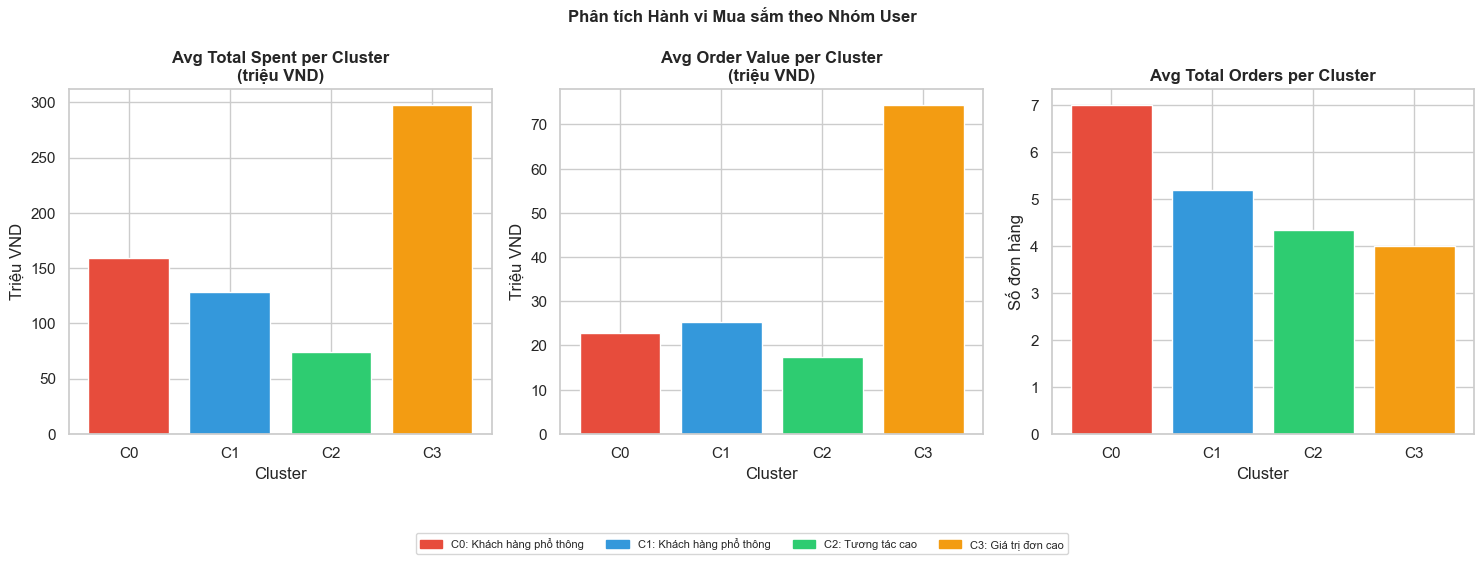

In [17]:
# Spending analysis per cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cluster_labels_list = [f"C{k}:{v['label'][:14]}" for k, v in user_summaries.items()]

# Total spent
for cid in unique_clusters_u:
    rows = user_df[user_df['cluster'] == cid]
    axes[0].bar(f"C{cid}", rows['total_spent'].mean() / 1e6,
                color=color_map_u[cid], edgecolor='white')
axes[0].set_title('Avg Total Spent per Cluster\n(triệu VND)', fontweight='bold')
axes[0].set_ylabel('Triệu VND')

# Avg order value
for cid in unique_clusters_u:
    rows = user_df[user_df['cluster'] == cid]
    axes[1].bar(f"C{cid}", rows['avg_order_value'].mean() / 1e6,
                color=color_map_u[cid], edgecolor='white')
axes[1].set_title('Avg Order Value per Cluster\n(triệu VND)', fontweight='bold')
axes[1].set_ylabel('Triệu VND')

# Total orders
for cid in unique_clusters_u:
    rows = user_df[user_df['cluster'] == cid]
    axes[2].bar(f"C{cid}", rows['total_orders'].mean(),
                color=color_map_u[cid], edgecolor='white')
axes[2].set_title('Avg Total Orders per Cluster', fontweight='bold')
axes[2].set_ylabel('Số đơn hàng')

for ax in axes:
    ax.set_xlabel('Cluster')

# Common legend
patches = [mpatches.Patch(color=color_map_u[c], label=f"C{c}: {user_summaries[c]['label']}")
           for c in unique_clusters_u]
fig.legend(handles=patches, loc='lower center', ncol=len(unique_clusters_u),
           bbox_to_anchor=(0.5, -0.12), fontsize=8)

plt.suptitle('Phân tích Hành vi Mua sắm theo Nhóm User', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Hiệu chỉnh tự động số cụm K bằng Elbow Method

Để tìm được số K tốt nhất mà không cần phỏng đoán, hệ thống dùng biểu đồ khuỷu tay (Elbow) đo Ineria. Điểm gãy đường cong chính là K tối ưu.

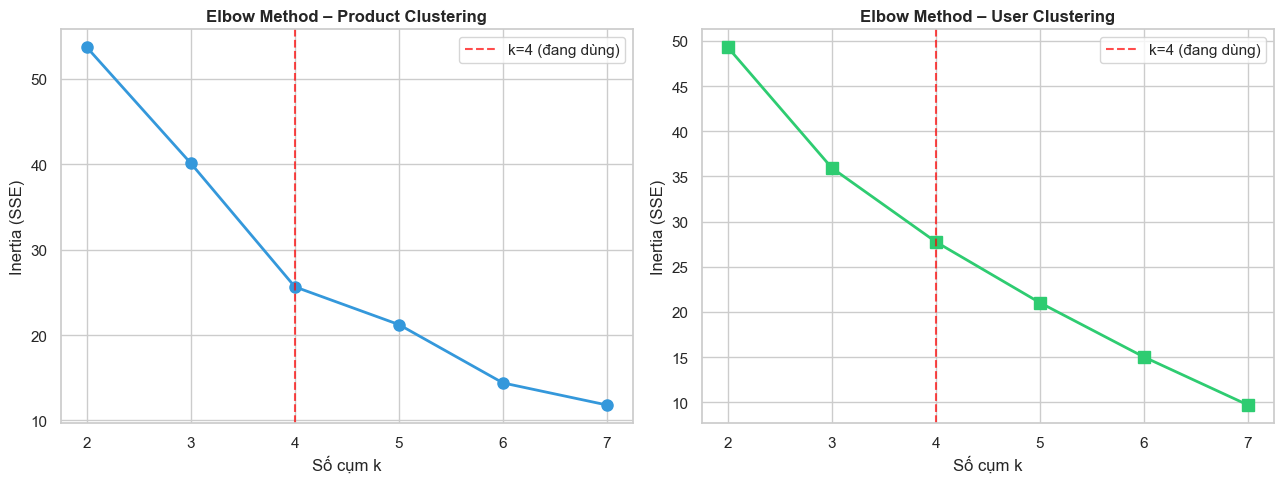

In [18]:
# Elbow method cho Product clustering
inertia_p = []
K_range   = range(2, min(8, len(prod_df)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_p.append(km.inertia_)

inertia_u = []
K_range_u = range(2, min(8, len(user_df)))
for k in K_range_u:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_usscaled)
    inertia_u.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertia_p, marker='o', color='#3498db', linewidth=2, markersize=8)
axes[0].axvline(x=N_CLUSTERS_PRODUCTS, color='red', linestyle='--', alpha=0.7, label=f'k={N_CLUSTERS_PRODUCTS} (đang dùng)')
axes[0].set_title('Elbow Method – Product Clustering', fontweight='bold')
axes[0].set_xlabel('Số cụm k')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].legend()

axes[1].plot(list(K_range_u), inertia_u, marker='s', color='#2ecc71', linewidth=2, markersize=8)
axes[1].axvline(x=n_clusters_u, color='red', linestyle='--', alpha=0.7, label=f'k={n_clusters_u} (đang dùng)')
axes[1].set_title('Elbow Method – User Clustering', fontweight='bold')
axes[1].set_xlabel('Số cụm k')
axes[1].set_ylabel('Inertia (SSE)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Kết quả cuối – Mỗi item trong cụm của nó

In [19]:
print('PRODUCT CLUSTERING RESULTS:')
for cid in sorted(prod_df['cluster'].unique()):
    members = prod_df[prod_df['cluster'] == cid]
    label   = cluster_summaries[cid]['label']
    print(f'\n  Cụm {cid} – [{label}] ({len(members)} SP):')
    for _, row in members.iterrows():
        print(f'    • {row["name"]:<35} price={row["price"]/1e6:.1f}M | sold={row["sold_count"]:.0f} | rating={row["average_rating"]:.1f}')

PRODUCT CLUSTERING RESULTS:

  Cụm 0 – [Nhóm phổ thông] (3 SP):
    • Bộ Bàn Ăn 6 Ghế                     price=8.9M | sold=46 | rating=2.5
    • Ghế họp                             price=2.0M | sold=30 | rating=3.0
    • Bàn Gỗ Điểm Nhấn                    price=0.5M | sold=39 | rating=4.0

  Cụm 1 – [Nhóm phổ thông] (2 SP):
    • Ghế Điểm Nhấn Larbell               price=10.0M | sold=55 | rating=0.0
    • Bàn Ceilby                          price=3.5M | sold=45 | rating=0.0

  Cụm 2 – [Nhóm phổ thông] (3 SP):
    • Sofa Góc Lullaby                    price=15.0M | sold=40 | rating=2.5
    • Sofa Băng Da Bò Thật                price=28.5M | sold=41 | rating=3.0
    • Sofa Giường Thông Minh              price=8.5M | sold=43 | rating=3.0

  Cụm 3 – [Nhóm phổ thông] (5 SP):
    • Sofa Đơn Thư Giãn                   price=4.2M | sold=55 | rating=4.0
    • Bàn Trà Kính Tròn                   price=2.5M | sold=47 | rating=5.0
    • Giường Ngủ Gỗ Sồi                   price=8.9M | sold=60 | 

In [22]:
print('\nUSER CLUSTERING RESULTS:')
for cid in sorted(user_df['cluster'].unique()):
    members = user_df[user_df['cluster'] == cid]
    label   = user_summaries[cid]['label']
    print(f'\n  Cụm {cid} – [{label}] ({len(members)} users):')
    
    for _, row in members.iterrows():
        print(
            f"    • ...{row['user_id'][-12:]:<15} "
            f"orders={row['total_orders']:.0f} | "
            f"spent={row['total_spent']/1e6:.1f}M | "
            f"avg_order={row['avg_order_value']/1e6:.1f}M | "
            f"reviews={row['total_reviews']:.0f}"
        )


USER CLUSTERING RESULTS:

  Cụm 0 – [Khách hàng phổ thông] (3 users):
    • ...43cb3a606532    orders=7 | spent=227.4M | avg_order=32.5M | reviews=3
    • ...bd4311631588    orders=7 | spent=121.4M | avg_order=17.3M | reviews=3
    • ...1702467bfe6d    orders=7 | spent=128.2M | avg_order=18.3M | reviews=3

  Cụm 1 – [Khách hàng phổ thông] (5 users):
    • ...c2f632e0f109    orders=6 | spent=204.8M | avg_order=34.1M | reviews=5
    • ...806f584309b3    orders=5 | spent=87.6M | avg_order=17.5M | reviews=3
    • ...93a08bc614dc    orders=4 | spent=146.3M | avg_order=36.6M | reviews=3
    • ...7636ad67f2a8    orders=5 | spent=141.3M | avg_order=28.3M | reviews=4
    • ...9c979a80511f    orders=6 | spent=62.1M | avg_order=10.3M | reviews=3

  Cụm 2 – [Tương tác cao] (3 users):
    • ...075387ee253c    orders=4 | spent=80.2M | avg_order=20.0M | reviews=5
    • ...e489af8a1579    orders=4 | spent=66.7M | avg_order=16.7M | reviews=5
    • ...e0c6afab3a12    orders=5 | spent=76.0M | avg_order=

## 7. Tóm tắt luồng xử lý

In [23]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         K-Means Clustering – Luồng Xử Lý                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PRODUCT CLUSTERING:                                             ║
║  1. products_to_df() → DataFrame với features số                 ║
║  2. features: price, avg_rating, total_reviews,                  ║
║               sold_count, stock, image_count, has_3d             ║
║  3. StandardScaler → chuẩn hoá                                   ║
║  4. KMeans(n_clusters=k, n_init=20) → cluster labels             ║
║  5. Rule-based labeling dựa trên quantile thresholds             ║
║                                                                  ║
║  USER CLUSTERING:                                                ║
║  1. Tổng hợp từ orders: total_orders, total_spent, total_qty     ║
║  2. Tổng hợp từ reviews: total_reviews, avg_rating               ║
║  3. → avg_order_value = total_spent / total_orders               ║
║  4. StandardScaler → KMeans → Rule-based labeling                ║
║                                                                  ║
║  OUTPUT:                                                         ║
║  {cluster_type, cluster_count, cluster_summaries, clusters}      ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         K-Means Clustering – Luồng Xử Lý                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PRODUCT CLUSTERING:                                             ║
║  1. products_to_df() → DataFrame với features số                 ║
║  2. features: price, avg_rating, total_reviews,                  ║
║               sold_count, stock, image_count, has_3d             ║
║  3. StandardScaler → chuẩn hoá                                   ║
║  4. KMeans(n_clusters=k, n_init=20) → cluster labels             ║
║  5. Rule-based labeling dựa trên quantile thresholds             ║
║                                                                  ║
║  USER CLUSTERING:                                                ║
║  1. Tổng hợp từ orders: total_orders, total_spent, total_qty     ║
║  2. Tổng hợp từ reviews: total_